# Shallow LSTM with Optuna & Symlog

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 32.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = 15
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
OPTUNA_TRIALS = 25

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing


In [ ]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                           "Leverage", "Cash_Ratio", "Size_SL",
                           "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"]
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, val_year, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc


## Pipeline Setup (Symlog, RobustScaler, Packing)

In [4]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

# SYMLOG TRANSFORMATION instead of Winsorization
idx_value = data_df["target"].isin(PREDICTION_TARGETS)
y_val = data_df.loc[idx_value, "label_value"]
data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# k-fold for HPO and single-split for final-test paths
folds, test_data = temporal_kfold_split(data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
train_data, val_data, _ = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

robust_scaler = make_robust_scaler(train_data, selected_indices) if not train_data.empty else RobustScaler()
print("Success: RobustScaler fitted correctly on single-split train (final-test path).")


Selected temporal features (26): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume', 'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom', 'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume']
Static features (3): ['MC_MIB', 'MC_MID', 'MC_SMALL']
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (3053), val = 2019 (418)
  Fold 2: train <= 2019 (3471), val = 2020 (444)
  Fold 3: train <= 2020 (3915), val = 2021 (455)
  Fold 4: train <= 2021 (4370), val = 2022 (474)
  Fold 5: train <= 2022 (4844), val = 2023 (489)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2

## Model Definitions

In [5]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits


## Helpers for Optuna and Evaluation

In [6]:
def extract_mtl_df(df: pd.DataFrame, static_dim: int | None = None) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        sd = group.iloc[0]["static_data"]
        if static_dim is not None:
            sd = np.asarray(sd, dtype=np.float32)[:static_dim]
        static_data = sd
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

# k-fold MTL lists for HPO: each entry = (mtl_train, mtl_val, val_year, fold_idx)
# Base pipeline uses only the first STATIC_DIM (=3) static components (MC dummies),
# preserving today's base-vs-improved contrast.
folds_mtl = [(extract_mtl_df(tr, static_dim=STATIC_DIM),
              extract_mtl_df(va, static_dim=STATIC_DIM), vy, fi)
             for (tr, va, vy, fi) in folds]

# Single-split MTL globals (largest fold + held-out test) for final-test evaluation paths

mtl_train_data = extract_mtl_df(train_data, static_dim=STATIC_DIM)
mtl_val_data = extract_mtl_df(val_data, static_dim=STATIC_DIM)
mtl_test_data = extract_mtl_df(test_data, static_dim=STATIC_DIM)

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size  # Store the desired sequence length

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        # 1. Extract the pre-computed window from the dataframe
        window = row["window_data"][:, self.feature_indices].copy()

        # 2. Truncate the window dynamically to match the fixed_window_size
        # We take the last 'window_size' steps to keep the most recent data
        if self.window_size is not None:
            window = window[-self.window_size:]

        # 3. Apply scaling if provided
        if self.scaler:
            window = self.scaler.transform(window)

        # 4. Extract static features and clean targets
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)

        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window)
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths


In [7]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Core Training Logic & Optuna Integration

In [ ]:
SYMLOG_CAP = float(np.log1p(3.0)) 

def train_and_eval(model, train_loader, val_loader, optimizer,  trial=None, loss_type='l1', huber_delta=1.0, step_offset=0):
    if loss_type == 'l1':
        criterion = nn.L1Loss(reduction='none')
    elif loss_type == 'mse':
        criterion = nn.MSELoss(reduction='none')
    elif loss_type == 'huber':
        criterion = nn.HuberLoss(delta=huber_delta, reduction='none')
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            bx, by, bmask, bstatic, lengths = batch
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        # Eval
        model.eval()
        all_preds = []
        all_targets = []
        all_masks = []
        with torch.no_grad():
            for batch in val_loader:
                bx, by, bmask, bstatic, lengths = batch
                bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                all_masks.append(bmask.numpy())
                all_preds.append(logits.cpu().numpy())
                all_targets.append(by.numpy())

        if len(all_preds) == 0:
            break

        y_pred = np.vstack(all_preds)
        y_true = np.vstack(all_targets)

        y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

        mask = np.vstack(all_masks)
        valid_sum, count = 0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0: continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = valid_sum / max(1, count)

        scheduler.step(current_metric)

        is_better = current_metric < best_metric
        if is_better:
            best_metric = current_metric
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if trial is not None:
            trial.report(current_metric, step_offset + epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric

def get_hpo_objective( loss_type='l1'):
    folds_local = folds_mtl
    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        huber_delta = trial.suggest_float("huber_delta", 0.8, 2.0) if loss_type == 'huber' else 1.0

        fold_metrics = []
        for (mtl_tr, mtl_va, val_year, fold_idx) in folds_local:
            step_offset = (fold_idx - 1) * MAX_EPOCHS
            # Per-fold scaler refit (no leakage from val year into scaling stats)
            fold_scaler = make_robust_scaler(mtl_tr, selected_indices)
            train_ds = YoYDatasetMTL(mtl_tr, fold_scaler, selected_indices)
            val_ds = YoYDatasetMTL(mtl_va, fold_scaler, selected_indices)
            model = ShallowLSTM(len(selected_indices), hidden_size, len(PREDICTION_TARGETS), dropout, static_dim=STATIC_DIM).to(DEVICE)

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_mtl)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_mtl)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

            _, best_metric = train_and_eval(
                model, train_loader, val_loader, optimizer,
                trial=trial, loss_type=loss_type, huber_delta=huber_delta, step_offset=step_offset
            )
            fold_metrics.append(best_metric)

            # Coarse per-fold pruning (step placed beyond this fold's epoch range)
            trial.report(float(np.mean(fold_metrics)), step_offset + MAX_EPOCHS)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return float(np.mean(fold_metrics))
    return objective

def evaluate_real_metrics(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []
    all_masks = []

    with torch.no_grad():

        for batch in loader:

            bx, by, bmask, bstatic, lengths = batch

            preds = model(
                bx.to(device),
                lengths,
                bstatic.to(device)
            )

            all_preds.append(preds.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks).astype(bool)

    # back to real scale (clip to winsor cap to prevent expm1 blow-up)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

    errors = np.abs(y_pred - y_true)
    squared_errors = (y_pred - y_true) ** 2

    mae = errors[mask].mean()
    rmse = np.sqrt(squared_errors[mask].mean())

    print(f"Test MAE  (Real Scale): {mae:.4f}")
    print(f"Test RMSE (Real Scale): {rmse:.4f}")

    return float(mae), float(rmse)


# Training

## Training & HPO


In [10]:
print("MTL (Comparing Losses)")
best_mtl = {}
for l_type in ['l1']:
    print(f"\nEvaluating with '{l_type}' Loss...")
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_{l_type}", pruner=pruner)
    study.optimize(get_hpo_objective( loss_type=l_type), n_trials=OPTUNA_TRIALS)
    best_mtl[l_type] = study.best_trial.params
    print(f"[{l_type.upper()} - MTL] Best Avg Val Metric (minimize): {study.best_value:.4f}")


[I 2026-07-02 21:27:38,384] A new study created in memory with name: mtl_l1


MTL (Comparing Losses)

Evaluating with 'l1' Loss...


[I 2026-07-02 21:30:22,854] Trial 0 finished with value: 4.196072578430176 and parameters: {'hidden_size': 64, 'lr': 0.0009519688938210528, 'batch_size': 64, 'weight_decay': 8.524842950611809e-06, 'dropout': 0.45892710551448745}. Best is trial 0 with value: 4.196072578430176.
[I 2026-07-02 21:34:42,483] Trial 1 finished with value: 4.197392463684082 and parameters: {'hidden_size': 64, 'lr': 0.00043103008502877064, 'batch_size': 16, 'weight_decay': 2.058563187749576e-06, 'dropout': 0.2606985854075826}. Best is trial 0 with value: 4.196072578430176.
[I 2026-07-02 21:37:51,471] Trial 2 finished with value: 4.204496383666992 and parameters: {'hidden_size': 32, 'lr': 0.00029708078535105147, 'batch_size': 64, 'weight_decay': 0.0007649840740179718, 'dropout': 0.35832711595496997}. Best is trial 0 with value: 4.196072578430176.
[I 2026-07-02 21:40:03,874] Trial 3 finished with value: 4.196578502655029 and parameters: {'hidden_size': 64, 'lr': 0.0003940588070025115, 'batch_size': 32, 'weight_de

[L1 - MTL] Best Avg Val Metric (minimize): 4.1790


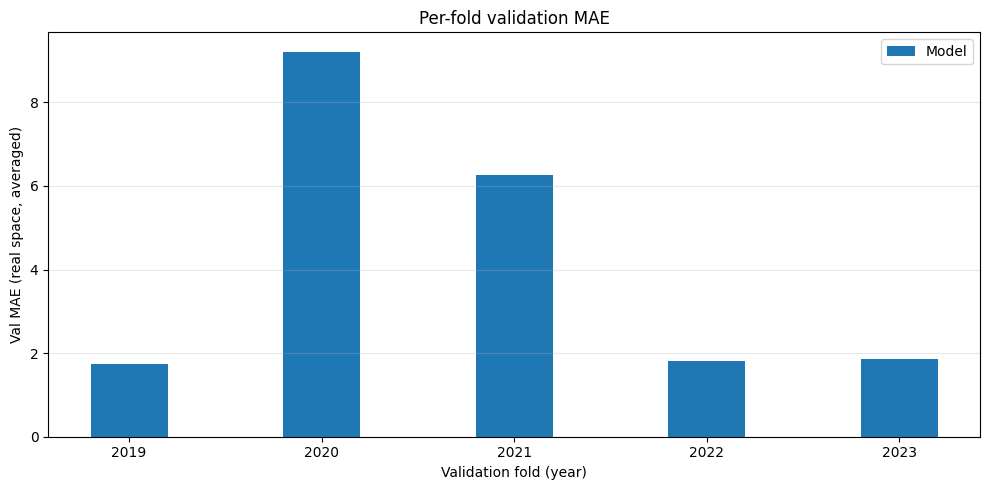

In [11]:
# Per-fold validation MAE: Model Evaluation
def eval_folds_per_target(params, loss_type='l1'):
    folds_local = folds_mtl
    val_years, maes = [], []
    for (mtl_tr, mtl_va, vy, fi) in folds_local:
        if True:
            fold_scaler = make_robust_scaler(mtl_tr, selected_indices)
            train_ds = YoYDatasetMTL(mtl_tr, fold_scaler, selected_indices)
            val_ds = YoYDatasetMTL(mtl_va, fold_scaler, selected_indices)
            collate = collate_fn_mtl
            model = ShallowLSTM(len(selected_indices), params['hidden_size'], len(PREDICTION_TARGETS), params.get('dropout',0.2), static_dim=STATIC_DIM).to(DEVICE)

        if collate:
            tr_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, collate_fn=collate)
            va_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate)
        else:
            tr_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            va_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)
        opt = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        _, best_metric = train_and_eval(model, tr_loader, va_loader, opt,  loss_type=loss_type, huber_delta=params.get('huber_delta',1.0))
        val_years.append(vy); maes.append(best_metric)
    return val_years, maes

params = best_mtl.get('l1', best_mtl)
iy, im = eval_folds_per_target(params)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(iy))
w = 0.4

# Generazione delle label usando esclusivamente l'anno
labels = [str(y) for y in iy]

ax.bar(x, im, width=w, label='Model')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('Validation fold (year)')
ax.set_ylabel('Val MAE (real space, averaged)')
ax.set_title('Per-fold validation MAE')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

In [12]:
def build_loaders_and_model(params):
    dropout_val = params.get("dropout", 0.2)
    train_ds = YoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
    val_ds = YoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)
    test_ds = YoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate_fn_mtl)
    val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            bx, by, bmask, bstatic, lengths = batch
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

N_RUNS = 20


## Worst results


### Loss Curves

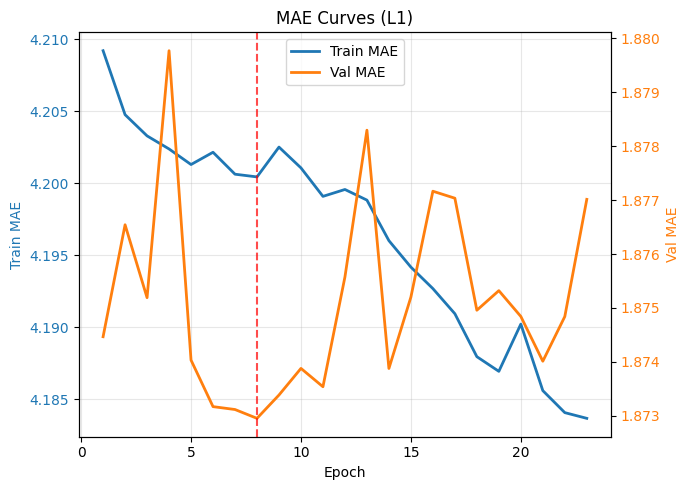

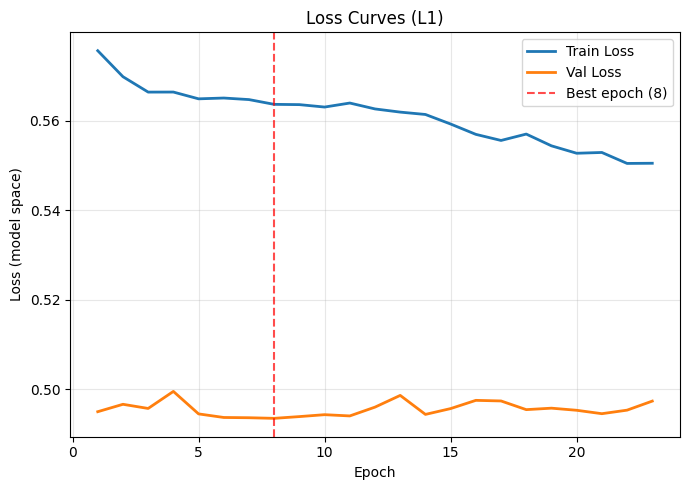

Model: 23 epochs, final train MAE=4.1837, final val MAE=1.8770 | final train loss=0.5505, final val loss=0.4974


In [ ]:
def train_and_eval_with_history(model, train_loader, val_loader, optimizer):
    criterion = nn.L1Loss(reduction='none')
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    history = {"train_mae": [], "val_mae": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        # --- Training step ---
        model.train()
        epoch_loss_sum = 0.0
        epoch_loss_count = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if True:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                mask_f = bmask.to(loss_m.dtype)
                loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
                epoch_loss_count += int(bmask.sum().item())
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
                loss_m = criterion(logits, by)
                mask_f = bmask.to(loss_m.dtype)
                loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
                epoch_loss_count += int(bmask.sum().item())

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        # --- Eval-mode MAE on train set ---
        model.eval()
        def compute_mae(loader):
            all_preds, all_targets, all_masks = [], [], []
            with torch.no_grad():
                for batch in loader:
                    if True:
                        bx, by, bmask, bstatic, lengths = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, lengths, bstatic)
                    else:
                        bx, bstatic, by, bmask = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, bstatic)
                    all_preds.append(logits.cpu().numpy())
                    all_targets.append(by.numpy())
                    all_masks.append(bmask.numpy())
            if not all_preds:
                return None
            y_pred = np.vstack(all_preds)
            y_true = np.vstack(all_targets)
            mask = np.vstack(all_masks).astype(bool)
            abs_err = np.abs(y_pred - y_true)
            if True:
                y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
                y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
                abs_err = np.abs(y_pred - y_true)
            return np.mean(abs_err[mask]) if mask.any() else 0.0

        def compute_loss(loader):
            total, count = 0.0, 0
            with torch.no_grad():
                for batch in loader:
                    if True:
                        bx, by, bmask, bstatic, lengths = batch
                        bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, lengths, bstatic)
                    else:
                        bx, bstatic, by, bmask = batch
                        bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, bstatic)
                    loss_m = criterion(logits, by)
                    mask_bool = bmask.bool()
                    if mask_bool.any():
                        total += loss_m[mask_bool].sum().item()
                        count += int(mask_bool.sum().item())
            return total / max(count, 1) if count > 0 else None

        train_mae = compute_mae(train_loader)
        val_mae = compute_mae(val_loader)
        val_loss = compute_loss(val_loader)
        if train_mae is None or val_mae is None or val_loss is None:
            break

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["val_loss"].append(val_loss)

        scheduler.step(val_mae)

        is_better = val_mae < best_metric
        if is_better:
            best_metric = val_mae
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric, history


best_l1 = best_mtl["l1"]

set_seed(SEED)
model, train_loader, val_loader, _ = build_loaders_and_model(best_l1)
optimizer = torch.optim.Adam(model.parameters(), lr=best_l1["lr"], weight_decay=best_l1["weight_decay"])
_, _, hist = train_and_eval_with_history(model, train_loader, val_loader, optimizer)

# --- MAE Curves ---
fig, primary_ax = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(hist["train_mae"]) + 1)

# Configure primary axis for Train MAE
train_color = 'tab:blue'
primary_ax.set_xlabel("Epoch")
primary_ax.set_ylabel("Train MAE", color=train_color)
train_line = primary_ax.plot(epochs_range, hist["train_mae"], color=train_color, label="Train MAE", linewidth=2)
primary_ax.tick_params(axis='y', labelcolor=train_color)

# Create a secondary axis sharing the same x-axis
secondary_ax = primary_ax.twinx()
val_color = 'tab:orange'
secondary_ax.set_ylabel("Val MAE", color=val_color)
val_line = secondary_ax.plot(epochs_range, hist["val_mae"], color=val_color, label="Val MAE", linewidth=2)
secondary_ax.tick_params(axis='y', labelcolor=val_color)

# Mark the best epoch on the secondary axis (since it relates to Val MAE)
best_epoch_idx = np.argmin(hist["val_mae"]) + 1
secondary_ax.axvline(x=best_epoch_idx, color='red', linestyle='--', alpha=0.7)

# Combine legends from both axes
all_lines = train_line + val_line
all_labels = [line.get_label() for line in all_lines]
primary_ax.legend(all_lines, all_labels, loc='upper center')

primary_ax.set_title("MAE Curves (L1)")
primary_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Loss curves (train vs val, model output space) ---
fig_loss, ax = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(hist["train_loss"]) + 1)

ax.plot(epochs_range, hist["train_loss"], label="Train Loss", linewidth=2)
ax.plot(epochs_range, hist["val_loss"], label="Val Loss", linewidth=2)
best_epoch = np.argmin(hist["val_mae"]) + 1
ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch})")

ax.set_title("Loss Curves (L1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (model space)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Model: {len(hist['train_mae'])} epochs, final train MAE={hist['train_mae'][-1]:.4f}, final val MAE={hist['val_mae'][-1]:.4f} | final train loss={hist['train_loss'][-1]:.4f}, final val loss={hist['val_loss'][-1]:.4f}")


### Untrained model baseline

In [ ]:
best_l1 = best_mtl["l1"]
baseline_results = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
for run_idx in range(N_RUNS):
    set_seed(SEED + run_idx)
    model, _, _, test_loader = build_loaders_and_model(best_l1)
    res = evaluate_loader(model, test_loader)
    for k, v in res.items():
        baseline_results[k].append(v)

print("Untrained baseline (averaged over N_RUNS seeds) — Test MAE (real scale):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = baseline_results[k]
    print(f"  {k:10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}  (n={len(vals)})")

Untrained baseline (averaged over N_RUNS seeds) — Test MAE (real scale):
  EBITDA    : 0.9086 ± 0.0398  (n=20)
  Net_Income: 0.9731 ± 0.0194  (n=20)
  ROA       : 0.9676 ± 0.0266  (n=20)
  Overall   : 0.9498 ± 0.0154  (n=20)


### Segmented Performance Analysis

In [ ]:
def evaluate_group_pipeline(best_params_dict):
    group_results = []

    for l_type, params in best_params_dict.items():
        group_run_maes = {grp: {t: [] for t in PREDICTION_TARGETS} for grp in ticker_groups.keys()}

        for run_idx in range(N_RUNS):
            set_seed(SEED + run_idx)
            model, train_loader, val_loader, _ = build_loaders_and_model(params)
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
            huber_delta = params.get("huber_delta", 1.0)
            model, _ = train_and_eval(model, train_loader, val_loader, optimizer, loss_type=l_type, huber_delta=huber_delta)

            for group_name, tickers in ticker_groups.items():
                group_df = mtl_test_data[mtl_test_data['company'].isin(tickers)]
                if group_df.empty: continue
                group_ds = YoYDatasetMTL(group_df, robust_scaler, selected_indices)
                collate = collate_fn_mtl

                loader = DataLoader(group_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
                metrics = evaluate_loader(model, loader)

                if metrics:
                    for target, val in metrics.items():
                        if target not in PREDICTION_TARGETS:
                            continue
                        group_run_maes[group_name][target].append(val)

        # Compute mean and std
        for group_name in ticker_groups.keys():
            for target in PREDICTION_TARGETS:
                if len(group_run_maes[group_name][target]) > 0:
                    maes = group_run_maes[group_name][target]
                    group_results.append({
                        "Loss": l_type.upper(),
                        "Group": group_name,
                        "Target": target,
                        "MAE (Mean)": np.mean(maes),
                        "Deviation": np.std(maes)
                    })

    return group_results

print("Evaluating MTL across losses and groups...")
group_stats = evaluate_group_pipeline(best_mtl)

df_group = pd.DataFrame(group_stats)

if df_group.empty:
    print("\nWARNING: No grouped results. The global test set may not contain all ticker groups.")
    print("Consider using the dedicated per-group pipeline for Mid-cap and Small-cap analysis.")


print("\n--- Grouped MAE: MTL ---")
if not df_group.empty:
    display(df_group.pivot_table(index=['Target', 'Loss'], columns='Group', values=['MAE (Mean)', 'Deviation']))
else:
    print("No data available for MTL grouping.")


Evaluating MTL across losses and groups...

--- Grouped MAE: MTL ---


Deviation                     MAE (Mean)                    
Group                 MIB   Mid-cap Small-cap        MIB   Mid-cap Small-cap
Target     Loss                                                             
EBITDA     L1    0.009808  0.027565  0.014285   0.308970  0.706047  1.206707
Net_Income L1    0.007901  0.023568  0.011993   0.387823  0.749937  1.299855
ROA        L1    0.010231  0.017003  0.009814   0.373646  0.576323  1.412472

## Best results

### Robust Target (Winsorized YoY Ratio)


In [ ]:
WINSOR_CAP = 3.0

sym_label = data_df["label_value"].to_numpy()
raw_ratio = np.sign(sym_label) * np.expm1(np.abs(sym_label))

capped_ratio = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
robust_label = (np.sign(capped_ratio) * np.log1p(np.abs(capped_ratio))).astype(np.float32)

data_df_robust = data_df.copy()
data_df_robust["label_value"] = robust_label

n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Raw YoY ratio: min={raw_ratio.min():.3f}, max={raw_ratio.max():.3f}")
print(f"Capped at +/-{int(WINSOR_CAP)}: {n_capped}/{len(raw_ratio)} samples "
      f"({100.0 * n_capped / len(raw_ratio):.2f}%) trimmed.")
print(f"Robust symlog label: min={robust_label.min():.3f}, max={robust_label.max():.3f}")

# Rebuild the single-split (largest fold + held-out test) on the robust-labelled data.
train_data_robust, val_data_robust, test_data_robust = split_to_single(
    data_df_robust, test_year_cutoff=TEST_YEAR_CUTOFF)

robust_scaler_single = make_robust_scaler(train_data_robust, selected_indices)

mtl_train_robust = extract_mtl_df(train_data_robust, static_dim=STATIC_DIM)
mtl_val_robust   = extract_mtl_df(val_data_robust,   static_dim=STATIC_DIM)
mtl_test_robust  = extract_mtl_df(test_data_robust,  static_dim=STATIC_DIM)


def build_loaders_robust(params):
    train_ds = YoYDatasetMTL(mtl_train_robust, robust_scaler_single, selected_indices)
    val_ds   = YoYDatasetMTL(mtl_val_robust,   robust_scaler_single, selected_indices)
    test_ds  = YoYDatasetMTL(mtl_test_robust,  robust_scaler_single, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.2), static_dim=STATIC_DIM).to(DEVICE)
    return model, train_loader, val_loader, test_loader


# --- Trained vs Untrained baseline on the robust target (N_RUNS seeds) ---
best_l1 = best_mtl["l1"]

trained_res   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}

for run_idx in range(N_RUNS):
    set_seed(SEED + run_idx)
    model_u, _, _, test_loader = build_loaders_robust(best_l1)
    for k, v in evaluate_loader(model_u, test_loader).items():
        untrained_res[k].append(v)

    set_seed(SEED + run_idx)
    model_t, train_loader, val_loader, test_loader = build_loaders_robust(best_l1)
    optimizer = torch.optim.Adam(model_t.parameters(), lr=best_l1["lr"], weight_decay=best_l1["weight_decay"])
    model_t, _ = train_and_eval(model_t, train_loader, val_loader, optimizer,
                                loss_type="l1", huber_delta=best_l1.get("huber_delta", 1.0))
    for k, v in evaluate_loader(model_t, test_loader).items():
        trained_res[k].append(v)

rows = []
for k in PREDICTION_TARGETS + ["Overall"]:
    rows.append({
        "Target": k,
        "Untrained MAE": np.mean(untrained_res[k]),
        "Untrained +/-": np.std(untrained_res[k]),
        "Trained MAE": np.mean(trained_res[k]),
        "Trained +/-": np.std(trained_res[k]),
        "Delta (Trained - Untrained)": np.mean(trained_res[k]) - np.mean(untrained_res[k]),
    })
df_robust_cmp = pd.DataFrame(rows).set_index("Target")
print(f"\nRobust target (YoY ratio winsorized at +/-{int(WINSOR_CAP)}, symlog) - "
      f"Test MAE (real space), {N_RUNS} runs:")
display(df_robust_cmp.round(4))


Raw YoY ratio: min=-1921.500, max=1748.500
Capped at +/-3: 541/5824 samples (9.29%) trimmed.
Robust symlog label: min=-1.386, max=1.386
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4844), val = 2023 (489)

Robust target (YoY ratio winsorized at +/-3, symlog) - Test MAE (real space), 20 runs:


,Untrained MAE,Untrained +/-,Trained MAE,Trained +/-,Delta (Trained - Untrained)
Target,,,,,
EBITDA,0.4966,0.0398,0.4772,0.0108,-0.0194
Net_Income,0.7140,0.0194,0.6979,0.0070,-0.0161
ROA,0.7208,0.0266,0.7055,0.0037,-0.0153
Overall,0.6441,0.0154,0.6271,0.0058,-0.0170


### Fundamentals + Prior Targets

Static features now combine the 3 MC dummies with the 9 prior-year
fundamental columns precomputed upstream in Merged_Dataset_yoy.csv
(symlog-transformed prior EBITDA / Net_Income / Net_Sales /
Operating_Expenses / FCF_Per_Share, prior ROA, leverage, cash ratio,
firm size). Samples whose prior-year fundamentals are missing (NaN in the
static vector) are dropped here.

Re-run HPO with dropout 0.05-0.4 on val years 2021-2023 (dropping the COVID
2020 fold that previously forced over-regularization), then compare trained
vs untrained MAE and plot loss curves.


In [ ]:
WINSOR_CAP = 3.0
NEW_STATIC_SLICE = slice(3, 12)  # dims 0:3 = MC dummies (passthrough), 3:12 = prior features

# Prior-year fundamentals are now precomputed upstream in Merged_Dataset_yoy.csv.
# Drop samples whose static vector has any NaN (i.e. prior-year fundamentals
# missing) — reproduces the previous in-notebook fund_map drop semantics.
static_nan_mask = data_df["static_data"].apply(
    lambda a: np.isnan(np.asarray(a, dtype=float)).any()
)
n_drop_missing = int(static_nan_mask.sum())
data_df_imp = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; "
      f"{len(data_df_imp)} remaining.")

# Winsorize the YoY ratio at +/-3 and re-apply symlog
sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(raw_ratio)} "
      f"({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 12

# HPO folds: val years 2021, 2022, 2023
folds_imp, test_data_imp = temporal_kfold_split(data_df_imp, n_splits=3, test_year_cutoff=TEST_YEAR_CUTOFF)
folds_imp_mtl = [(extract_mtl_df(tr), extract_mtl_df(va), vy, fi) for (tr, va, vy, fi) in folds_imp]

# Single-split (largest fold) for final test evaluation.
train_data_imp, val_data_imp, _ = split_to_single(data_df_imp, test_year_cutoff=TEST_YEAR_CUTOFF)
mtl_train_imp_raw = extract_mtl_df(train_data_imp)
mtl_val_imp_raw   = extract_mtl_df(val_data_imp)
mtl_test_imp      = extract_mtl_df(test_data_imp)

def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df


def build_loaders_imp(params):
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train_imp_raw, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val_imp_raw,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test_imp,      stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.2), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader


# 6. HPO objective: dropout 0.05-0.4, 3 folds (val 2021-2023), per-fold static scaler.
def get_hpo_objective_imp(loss_type="l1"):
    folds_local = folds_imp_mtl
    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.05, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 0.8, 2.0) if loss_type == "huber" else 1.0

        fold_metrics = []
        for (mtl_tr_raw, mtl_va_raw, vy, fi) in folds_local:
            step_offset = (fi - 1) * MAX_EPOCHS
            fold_temp_sc = make_robust_scaler(mtl_tr_raw, selected_indices)
            fold_stat_sc = fit_static_scaler(mtl_tr_raw)
            train_ds = YoYDatasetMTL(apply_static_scaler(mtl_tr_raw, fold_stat_sc), fold_temp_sc, selected_indices)
            val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_va_raw, fold_stat_sc), fold_temp_sc, selected_indices)
            model = ShallowLSTM(len(selected_indices), hidden_size, len(PREDICTION_TARGETS),
                                dropout, static_dim=STATIC_DIM_IMP).to(DEVICE)
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn_mtl)
            val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn_mtl)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            _, best_metric = train_and_eval(model, train_loader, val_loader, optimizer,
                                            trial=trial, loss_type=loss_type,
                                            huber_delta=huber_delta, step_offset=step_offset)
            fold_metrics.append(best_metric)
            trial.report(float(np.mean(fold_metrics)), step_offset + MAX_EPOCHS)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return float(np.mean(fold_metrics))
    return objective

print(f"\nImproved-pipeline HPO: {OPTUNA_TRIALS} trials, dropout 0.05-0.4, val years 2021-2023.")
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
study_imp = optuna.create_study(direction="minimize", study_name="mtl_imp_l1", pruner=pruner)
study_imp.optimize(get_hpo_objective_imp(loss_type="l1"), n_trials=OPTUNA_TRIALS)
best_mtl_imp = {"l1": study_imp.best_trial.params}
print(f"\n[Improved - L1] Best Avg Val Metric (minimize): {study_imp.best_value:.4f}")
print(f"[Improved - L1] Best params: {best_mtl_imp['l1']}")


Fundamentals map: 2106 (company, year) entries with all 6 fields.
Dropped 70 samples missing prior-year fundamentals; 5754 remaining (5754 rows).
Robust symlog label: capped 527/5754 (9.16%) at +/-3.
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (3 folds, expanding window). Val years: [2021, 2022, 2023]
  Fold 1: train <= 2020 (3855), val = 2021 (451)
  Fold 2: train <= 2021 (4306), val = 2022 (468)
  Fold 3: train <= 2022 (4774), val = 2023 (489)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4774), val = 2023 (489)


[I 2026-07-02 22:27:40,261] A new study created in memory with name: mtl_imp_l1



Improved-pipeline HPO: 25 trials, dropout 0.05-0.4, val years 2021-2023.


[I 2026-07-02 22:29:24,775] Trial 0 finished with value: 0.7218202948570251 and parameters: {'hidden_size': 128, 'lr': 0.0058137650161888205, 'batch_size': 32, 'weight_decay': 0.00010635079109445105, 'dropout': 0.14319328573650836}. Best is trial 0 with value: 0.7218202948570251.
[I 2026-07-02 22:31:53,404] Trial 1 finished with value: 0.7518671154975891 and parameters: {'hidden_size': 128, 'lr': 0.0002607490356565955, 'batch_size': 64, 'weight_decay': 2.2084086200413866e-05, 'dropout': 0.24092575141232941}. Best is trial 0 with value: 0.7218202948570251.
[I 2026-07-02 22:34:14,514] Trial 2 finished with value: 0.7341610789299011 and parameters: {'hidden_size': 64, 'lr': 0.004191971892934502, 'batch_size': 16, 'weight_decay': 2.1420090667378873e-06, 'dropout': 0.09950458325176378}. Best is trial 0 with value: 0.7218202948570251.
/tmp/ipykernel_5058/3844096623.py:131: UserWarning: The reported value is ignored because this `step` 100 is already reported.
  trial.report(float(np.mean(fol


[Improved - L1] Best Avg Val Metric (minimize): 0.7134
[Improved - L1] Best params: {'hidden_size': 128, 'lr': 0.009318737603962767, 'batch_size': 32, 'weight_decay': 1.089481599031888e-05, 'dropout': 0.27709729352380763}


In [ ]:
# --- 20-seed trained vs untrained MAE on the improved pipeline (real space) ---
best_l1_imp = best_mtl_imp["l1"]
trained_res_imp   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res_imp = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}

for run_idx in range(N_RUNS):
    set_seed(SEED + run_idx)
    model_u, _, _, test_loader = build_loaders_imp(best_l1_imp)
    for k, v in evaluate_loader(model_u, test_loader).items():
        untrained_res_imp[k].append(v)

    set_seed(SEED + run_idx)
    model_t, train_loader, val_loader, test_loader = build_loaders_imp(best_l1_imp)
    optimizer = torch.optim.Adam(model_t.parameters(), lr=best_l1_imp["lr"], weight_decay=best_l1_imp["weight_decay"])
    model_t, _ = train_and_eval(model_t, train_loader, val_loader, optimizer,
                                loss_type="l1", huber_delta=best_l1_imp.get("huber_delta", 1.0))
    for k, v in evaluate_loader(model_t, test_loader).items():
        trained_res_imp[k].append(v)

rows = []
for k in PREDICTION_TARGETS + ["Overall"]:
    rows.append({
        "Target": k,
        "Untrained MAE": np.mean(untrained_res_imp[k]),
        "Untrained +/-": np.std(untrained_res_imp[k]),
        "Trained MAE": np.mean(trained_res_imp[k]),
        "Trained +/-": np.std(trained_res_imp[k]),
        "Delta (Trained - Untrained)": np.mean(trained_res_imp[k]) - np.mean(untrained_res_imp[k]),
    })
df_imp_cmp = pd.DataFrame(rows).set_index("Target")
print(f"\nImproved pipeline (fundamentals + prior targets, winsorized +/-{int(WINSOR_CAP)}) - "
      f"Test MAE (real space), {N_RUNS} runs:")
display(df_imp_cmp.round(4))



Improved pipeline (fundamentals + prior targets, winsorized +/-3) - Test MAE (real space), 20 runs:


,Untrained MAE,Untrained +/-,Trained MAE,Trained +/-,Delta (Trained - Untrained)
Target,,,,,
EBITDA,0.5166,0.0343,0.4414,0.0063,-0.0752
Net_Income,0.7403,0.0382,0.6688,0.0068,-0.0715
ROA,0.7448,0.0467,0.6865,0.0077,-0.0584
Overall,0.6676,0.0269,0.5992,0.0058,-0.0684


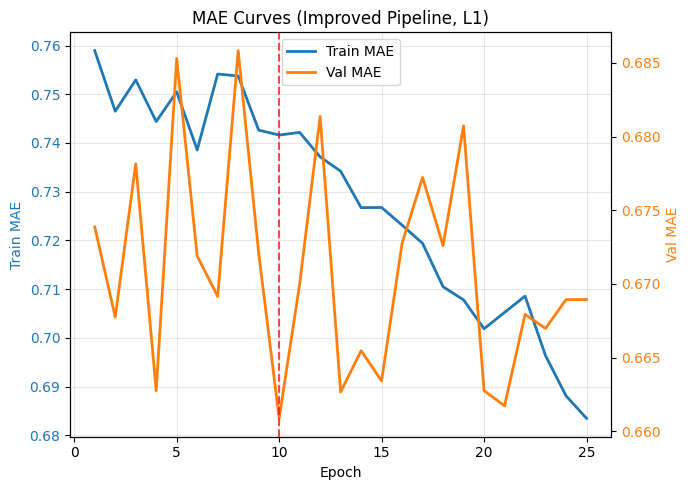

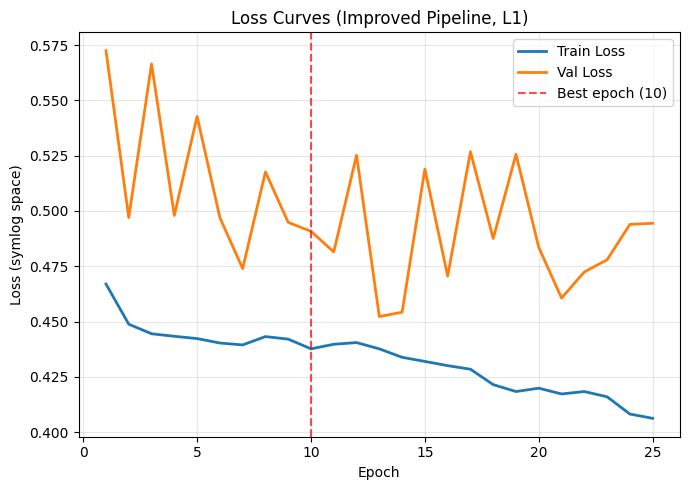

Improved model: 25 epochs, final train MAE=0.6835, final val MAE=0.6689 | final train loss=0.4062, final val loss=0.4944


In [ ]:
def train_and_eval_with_history_imp(model, train_loader, val_loader, optimizer):
    criterion = nn.L1Loss(reduction="none")
    scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)
    best_state, best_metric, no_improve = None, float("inf"), 0
    history = {"train_mae": [], "val_mae": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        ep_loss_sum, ep_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            ep_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            ep_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        history["train_loss"].append(ep_loss_sum / max(ep_loss_count, 1))

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp = np.sign(yp) * np.expm1(np.abs(yp))
            yt = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp - yt)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)
        scheduler.step(va_mae)
        if va_mae < best_metric:
            best_metric = va_mae
            best_state = {n: t.detach().cpu().clone() for n, t in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric, history


best_l1_imp = best_mtl_imp["l1"]
set_seed(SEED)
model, train_loader, val_loader, _ = build_loaders_imp(best_l1_imp)
optimizer = torch.optim.Adam(model.parameters(), lr=best_l1_imp["lr"], weight_decay=best_l1_imp["weight_decay"])
_, _, hist = train_and_eval_with_history_imp(model, train_loader, val_loader, optimizer)

# --- MAE curves (train vs val, real space) ---
fig, primary_ax = plt.subplots(1, 1, figsize=(7, 5))
epochs_range = range(1, len(hist["train_mae"]) + 1)
train_color = "tab:blue"
primary_ax.set_xlabel("Epoch")
primary_ax.set_ylabel("Train MAE", color=train_color)
train_line = primary_ax.plot(epochs_range, hist["train_mae"], color=train_color, label="Train MAE", linewidth=2)
primary_ax.tick_params(axis="y", labelcolor=train_color)
secondary_ax = primary_ax.twinx()
val_color = "tab:orange"
secondary_ax.set_ylabel("Val MAE", color=val_color)
val_line = secondary_ax.plot(epochs_range, hist["val_mae"], color=val_color, label="Val MAE", linewidth=2)
secondary_ax.tick_params(axis="y", labelcolor=val_color)
best_epoch_idx = int(np.argmin(hist["val_mae"])) + 1
secondary_ax.axvline(x=best_epoch_idx, color="red", linestyle="--", alpha=0.7)
all_lines = train_line + val_line
all_labels = [line.get_label() for line in all_lines]
primary_ax.legend(all_lines, all_labels, loc="upper center")
primary_ax.set_title("MAE Curves (Improved Pipeline, L1)")
primary_ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Loss curves (train vs val, symlog-space L1 = what is optimized) ---
fig_loss, ax = plt.subplots(1, 1, figsize=(7, 5))
epochs_range = range(1, len(hist["train_loss"]) + 1)
ax.plot(epochs_range, hist["train_loss"], label="Train Loss", linewidth=2)
ax.plot(epochs_range, hist["val_loss"], label="Val Loss", linewidth=2)
best_epoch = int(np.argmin(hist["val_mae"])) + 1
ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
ax.set_title("Loss Curves (Improved Pipeline, L1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (symlog space)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Improved model: {len(hist['train_mae'])} epochs, "
      f"final train MAE={hist['train_mae'][-1]:.4f}, final val MAE={hist['val_mae'][-1]:.4f} | "
      f"final train loss={hist['train_loss'][-1]:.4f}, final val loss={hist['val_loss'][-1]:.4f}")


## Direction Classification (Up/Down)

The regression model's directional accuracy is near chance (EBITDA 0.63, Net_Income 0.56,
ROA 0.52). We instead train a direct per-target binary classifier (up/down) with
`BCEWithLogitsLoss`, reusing the Optuna hyperparameters, and report Accuracy / Precision /
Recall / F1, a 2x2 confusion matrix, and per-market-cap accuracy.


In [ ]:
# --- Direction classification: predict whether YoY earnings go UP (1) or DOWN (0) ---
# The regression target's heavy tail makes real-space MAE outlier-dominated and the
# regression model's directional accuracy sits near chance. We instead train a direct
# per-target binary classifier with BCEWithLogitsLoss, reusing the Optuna hyperparameters.

sym_label = data_df["label_value"].to_numpy()
raw_ratio = np.sign(sym_label) * np.expm1(np.abs(sym_label))
data_df_cls = data_df.copy()
data_df_cls["direction"] = (raw_ratio > 0).astype(np.float32)

train_cls_df, val_cls_df, test_cls_df = split_to_single(data_df_cls, test_year_cutoff=TEST_YEAR_CUTOFF)
cls_scaler = make_robust_scaler(train_cls_df, selected_indices)


def extract_cls_df(df):
    records = []
    for (company, year), group in df.groupby(["company", "year"]):
        direction = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                direction[i] = t_row.iloc[0]["direction"]
        records.append({
            "company": company, "year": year, "year_end_date": group.iloc[0]["year_end_date"],
            "window_data": group.iloc[0]["window_data"], "static_data": group.iloc[0]["static_data"],
            "direction": direction,
        })
    return pd.DataFrame(records)


mtl_train_cls = extract_cls_df(train_cls_df)
mtl_val_cls   = extract_cls_df(val_cls_df)
mtl_test_cls  = extract_cls_df(test_cls_df)


class YoYDatasetCls(Dataset):
    def __init__(self, cls_df, scaler, feature_indices, window_size=None):
        self.data_df = cls_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler:
            window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        direction = row["direction"]
        mask = ~np.isnan(direction)
        direction_clean = np.nan_to_num(direction, nan=0.0)
        return (torch.from_numpy(window),
                torch.from_numpy(static),
                torch.tensor(direction_clean, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.bool),
                len(window))


def collate_fn_cls(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    dirs = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded, dirs, masks, statics, lengths


def build_loaders_cls(params):
    train_ds = YoYDatasetCls(mtl_train_cls, cls_scaler, selected_indices)
    val_ds   = YoYDatasetCls(mtl_val_cls,   cls_scaler, selected_indices)
    test_ds  = YoYDatasetCls(mtl_test_cls,  cls_scaler, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_cls)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_cls)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_cls)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.2), static_dim=STATIC_DIM).to(DEVICE)
    return model, train_loader, val_loader, test_loader


def train_and_eval_cls(model, train_loader, val_loader, optimizer,
                       max_epochs=MAX_EPOCHS, patience=PATIENCE):
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)
    best_state, best_metric, no_improve = None, -1.0, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            if loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        model.eval()
        L, Y, M = [], [], []
        with torch.no_grad():
            for bx, by, bmask, bstatic, lengths in val_loader:
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                L.append(logits.cpu().numpy()); Y.append(by.numpy()); M.append(bmask.numpy())
        logits, y, mask = np.vstack(L), np.vstack(Y), np.vstack(M).astype(bool)
        preds = (logits > 0).astype(np.float32)
        accs = [np.mean(preds[mask[:, i], i] == y[mask[:, i], i])
                for i in range(len(PREDICTION_TARGETS)) if mask[:, i].sum() > 0]
        metric = float(np.mean(accs)) if accs else 0.0
        scheduler.step(metric)
        if metric > best_metric:
            best_metric = metric
            best_state = {n: t.detach().cpu().clone() for n, t in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric


def evaluate_cls(model, loader):
    model.eval()
    L, Y, M = [], [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            L.append(logits.cpu().numpy()); Y.append(by.numpy()); M.append(bmask.numpy())
    logits, y, mask = np.vstack(L), np.vstack(Y), np.vstack(M).astype(bool)
    preds = (logits > 0).astype(np.float32)
    out = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        yt, yp = y[m, i], preds[m, i]
        tp = int(np.sum((yp == 1) & (yt == 1)))
        fp = int(np.sum((yp == 1) & (yt == 0)))
        fn = int(np.sum((yp == 0) & (yt == 1)))
        tn = int(np.sum((yp == 0) & (yt == 0)))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        out[t] = {"accuracy": float(np.mean(yp == yt)), "precision": prec, "recall": rec,
                  "f1": f1, "n": int(m.sum()), "TP": tp, "FP": fp, "FN": fn, "TN": tn}
    return out


# --- Train N_RUNS classifiers and aggregate (overall + per market-cap group) ---
best_l1 = best_mtl["l1"]
agg = {t: {k: [] for k in ["accuracy", "precision", "recall", "f1"]} for t in PREDICTION_TARGETS}
conf_sum = {t: np.array([0.0, 0.0, 0.0, 0.0]) for t in PREDICTION_TARGETS}
n_per_target = {t: 0 for t in PREDICTION_TARGETS}
group_acc = {g: {t: [] for t in PREDICTION_TARGETS} for g in ticker_groups}

group_test_loaders = {}
for g, tickers in ticker_groups.items():
    g_df = mtl_test_cls[mtl_test_cls["company"].isin(tickers)]
    if g_df.empty:
        continue
    g_ds = YoYDatasetCls(g_df, cls_scaler, selected_indices)
    group_test_loaders[g] = DataLoader(g_ds, batch_size=best_l1["batch_size"], shuffle=False, collate_fn=collate_fn_cls)

for run_idx in range(N_RUNS):
    set_seed(SEED + run_idx)
    model, train_loader, val_loader, test_loader = build_loaders_cls(best_l1)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_l1["lr"], weight_decay=best_l1["weight_decay"])
    model, _ = train_and_eval_cls(model, train_loader, val_loader, optimizer)

    res = evaluate_cls(model, test_loader)
    for t, m in res.items():
        for k in ["accuracy", "precision", "recall", "f1"]:
            agg[t][k].append(m[k])
        conf_sum[t] += np.array([m["TP"], m["FP"], m["FN"], m["TN"]])
        n_per_target[t] = m["n"]

    for g, g_loader in group_test_loaders.items():
        g_res = evaluate_cls(model, g_loader)
        for t, m in g_res.items():
            group_acc[g][t].append(m["accuracy"])

print(f"Direction classification (up/down) - test set, averaged over {N_RUNS} runs:")
rows = []
for t in PREDICTION_TARGETS:
    rows.append({
        "Target": t,
        "Accuracy": np.mean(agg[t]["accuracy"]),
        "Accuracy +/-": np.std(agg[t]["accuracy"]),
        "Precision": np.mean(agg[t]["precision"]),
        "Recall": np.mean(agg[t]["recall"]),
        "F1": np.mean(agg[t]["f1"]),
        "N": n_per_target[t],
    })
df_cls = pd.DataFrame(rows).set_index("Target")
display(df_cls.round(4))

print("\nAccuracy by market-cap group:")
g_rows = []
for g in ticker_groups:
    for t in PREDICTION_TARGETS:
        if group_acc[g][t]:
            g_rows.append({"Group": g, "Target": t,
                           "Accuracy": np.mean(group_acc[g][t]),
                           "Accuracy +/-": np.std(group_acc[g][t])})
df_gacc = pd.DataFrame(g_rows).pivot(index="Target", columns="Group", values="Accuracy")
display(df_gacc.round(4))

print("\nAverage confusion matrix per run (rows = true, cols = predicted):")
for t in PREDICTION_TARGETS:
    tp, fp, fn, tn = conf_sum[t] / N_RUNS
    cm = pd.DataFrame([[tn, fp], [fn, tp]],
                      index=["True Down (0)", "True Up (1)"],
                      columns=["Pred Down (0)", "Pred Up (1)"]).round(1)
    print(f"\n  {t}:")
    display(cm)


Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4844), val = 2023 (489)
Direction classification (up/down) - test set, averaged over 20 runs:


,Accuracy,Accuracy +/-,Precision,Recall,F1,N
Target,,,,,,
EBITDA,0.6356,0.0030,0.6371,0.9962,0.7772,163
Net_Income,0.5713,0.0028,0.5735,0.9840,0.7246,164
ROA,0.5015,0.0211,0.4970,0.6975,0.5601,164



Accuracy by market-cap group:


Group,MIB,Mid-cap,Small-cap
Target,,,
EBITDA,0.7586,0.7358,0.5325
Net_Income,0.7586,0.6038,0.4901
ROA,0.5638,0.5028,0.4809



Average confusion matrix per run (rows = true, cols = predicted):

  EBITDA:


,Pred Down (0),Pred Up (1)
True Down (0),0.0,59.0
True Up (1),0.4,103.6



  Net_Income:


,Pred Down (0),Pred Up (1)
True Down (0),1.2,68.8
True Up (1),1.5,92.5



  ROA:


,Pred Down (0),Pred Up (1)
True Down (0),25.8,57.2
True Up (1),24.5,56.5


## Specialized Models by Market Cap

In [ ]:
def run_dedicated_pipeline(group_name, tickers, loss_type='l1'):
    print(f"\n--- Dedicated Pipeline: {group_name} ({loss_type.upper()}) ---")

    group_df = data_df[data_df['company'].isin(tickers)].copy()
    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        return [], None

    try:
        g_folds, g_test = temporal_kfold_split(group_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        return [], None

    if g_test.equals(group_df) or len(g_folds) == 0:
        print(f"Skipping {group_name}: not enough folds/years.")
        return [], None

    g_folds_mtl = [(extract_mtl_df(tr, static_dim=STATIC_DIM),
                  extract_mtl_df(va, static_dim=STATIC_DIM), vy, fi)
                 for (tr, va, vy, fi) in g_folds]
    g_mtl_test = extract_mtl_df(g_test, static_dim=STATIC_DIM)

    fixed_window_size = None  # Use full 365-day lookback (no truncation)

    def group_objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)

        fold_metrics = []
        for (g_mtl_train, g_mtl_val, vy, fi) in g_folds_mtl:
            g_scaler = make_robust_scaler(g_mtl_train, selected_indices)
            train_ds = YoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
            val_ds = YoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_mtl)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_mtl)
            model = ShallowLSTM(
                input_size=len(selected_indices),
                hidden_size=hidden_size,
                num_targets=len(PREDICTION_TARGETS),
                dropout=dropout,
                static_dim=STATIC_DIM
            ).to(DEVICE)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            _, best_metric = train_and_eval(
                model=model, train_loader=train_loader, val_loader=val_loader,
                optimizer=optimizer, trial=None, loss_type=loss_type
            )
            fold_metrics.append(best_metric)
            trial.report(float(np.mean(fold_metrics)), fi)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return float(np.mean(fold_metrics))

    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_{group_name}", pruner=pruner)
    study.optimize(group_objective, n_trials=OPTUNA_TRIALS)

    best_params = study.best_trial.params
    print(f"Best Params for {group_name}: {best_params}\n")

    # Final retrain on the single split (largest fold) + test on held-out 2024
    g_train, g_val, _ = split_to_single(group_df, test_year_cutoff=TEST_YEAR_CUTOFF)
    g_scaler = make_robust_scaler(g_train, selected_indices)
    g_mtl_train = extract_mtl_df(g_train, static_dim=STATIC_DIM)
    g_mtl_val = extract_mtl_df(g_val, static_dim=STATIC_DIM)

    target_results = {t: [] for t in PREDICTION_TARGETS}

    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)

        train_ds = YoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
        val_ds = YoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)
        test_ds = YoYDatasetMTL(g_mtl_test, g_scaler, selected_indices, window_size=fixed_window_size)

        train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True, collate_fn=collate_fn_mtl)
        val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
        test_loader = DataLoader(test_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)

        dropout_val = best_params.get("dropout", 0.2)

        model = ShallowLSTM(
            input_size=len(selected_indices),
            hidden_size=best_params["hidden_size"],
            num_targets=len(PREDICTION_TARGETS),
            dropout=dropout_val,
            static_dim=STATIC_DIM
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

        model, _ = train_and_eval(
            model=model, train_loader=train_loader, val_loader=val_loader,
            optimizer=optimizer, trial=None, loss_type=loss_type
        )

        res = evaluate_loader(model, test_loader)

        if res:
            for target, val in res.items():
                if target not in PREDICTION_TARGETS:
                    continue
                target_results[target].append(val)

    group_stats = []

    for target in PREDICTION_TARGETS:
        if not target_results[target]:
            print(f"  NOTE: {target} has no valid data for {group_name}. Skipping.")
            continue

        avg_mae = np.mean(target_results[target])
        std_mae = np.std(target_results[target])

        group_stats.append({
            "Group": group_name,
            "Target": target,
            "Dedicated Test MAE": avg_mae,
            "Dedicated Deviation": std_mae
        })

    valid_means = [np.mean(target_results[t]) for t in PREDICTION_TARGETS if target_results[t]]
    if valid_means:
        total_mae = np.mean(valid_means)
        total_std = np.std(valid_means)

        print(f"{group_name} - Total Test MAE: {total_mae:.4f} ± {total_std:.4f}")

        group_stats.append({
            "Group": group_name,
            "Target": "TOTAL",
            "Dedicated Test MAE": total_mae,
            "Dedicated Deviation": total_std
        })

    return group_stats, best_params

dedicated_all_stats = []
dedicated_best_params = {}
for group_name, tickers in ticker_groups.items():
    stats, params = run_dedicated_pipeline(group_name, tickers, loss_type='l1')
    if params is not None:
        dedicated_best_params[group_name] = params
    if stats:
        dedicated_all_stats.extend(stats)

df_dedicated = pd.DataFrame(dedicated_all_stats)
pivot_result = df_dedicated.pivot(index='Target', columns='Group', values='Dedicated Test MAE')
print("\nNote: NaN indicates no valid data for that target/group combination.")
display(pivot_result.fillna("N/A"))



--- Dedicated Pipeline: MIB (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (87 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (596), val = 2019 (78)
  Fold 2: train <= 2019 (674), val = 2020 (84)
  Fold 3: train <= 2020 (758), val = 2021 (83)
  Fold 4: train <= 2021 (841), val = 2022 (83)
  Fold 5: train <= 2022 (924), val = 2023 (87)


[I 2026-06-30 00:51:54,586] A new study created in memory with name: mtl_MIB
[I 2026-06-30 00:52:18,633] Trial 0 finished with value: 1.9999961853027344 and parameters: {'hidden_size': 64, 'lr': 0.000506654387470485, 'batch_size': 64, 'weight_decay': 1.0474567826287581e-06, 'dropout': 0.13899628693081156}. Best is trial 0 with value: 1.9999961853027344.
[I 2026-06-30 00:53:00,781] Trial 1 finished with value: 1.9674838781356812 and parameters: {'hidden_size': 32, 'lr': 0.0007548653660481838, 'batch_size': 64, 'weight_decay': 1.0847015073889351e-06, 'dropout': 0.3442506632305663}. Best is trial 1 with value: 1.9674838781356812.
[I 2026-06-30 00:53:42,854] Trial 2 finished with value: 1.9684007167816162 and parameters: {'hidden_size': 64, 'lr': 0.001393129688254706, 'batch_size': 16, 'weight_decay': 0.00021854177142206056, 'dropout': 0.41010015430295244}. Best is trial 1 with value: 1.9674838781356812.
[I 2026-06-30 00:54:28,311] Trial 3 finished with value: 1.9586340188980103 and parame

Best Params for MIB: {'hidden_size': 32, 'lr': 0.006306896600456772, 'batch_size': 32, 'weight_decay': 0.0001362615656091673, 'dropout': 0.4318703011193903}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (87 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (924), val = 2023 (87)
MIB - Total Test MAE: 0.3636 ± 0.0371

--- Dedicated Pipeline: Mid-cap (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (159 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (906), val = 2019 (130)
  Fold 2: train <= 2019 (1036), val = 2020 (138)
  Fold 3: train <= 2020 (1174), val = 2021 (141)
  Fold 4: train <= 2021 (1315), val = 2022 (153)
  Fold 5: train <= 2022 (1468), val = 2023 (156)


[I 2026-06-30 01:07:45,350] A new study created in memory with name: mtl_Mid-cap
[I 2026-06-30 01:09:03,704] Trial 0 finished with value: 1.3693526983261108 and parameters: {'hidden_size': 32, 'lr': 0.00021777262778488072, 'batch_size': 16, 'weight_decay': 0.00015610528640315122, 'dropout': 0.1976181590612067}. Best is trial 0 with value: 1.3693526983261108.
[I 2026-06-30 01:09:49,713] Trial 1 finished with value: 1.3654190301895142 and parameters: {'hidden_size': 64, 'lr': 0.00028357026717662704, 'batch_size': 64, 'weight_decay': 4.733198181939807e-06, 'dropout': 0.21770653037032603}. Best is trial 1 with value: 1.3654190301895142.
[I 2026-06-30 01:10:32,874] Trial 2 finished with value: 1.361497163772583 and parameters: {'hidden_size': 32, 'lr': 0.0008913115003885188, 'batch_size': 64, 'weight_decay': 0.0004559333748276672, 'dropout': 0.1537327615595359}. Best is trial 2 with value: 1.361497163772583.
[I 2026-06-30 01:11:14,447] Trial 3 finished with value: 1.3558162450790405 and par

Best Params for Mid-cap: {'hidden_size': 128, 'lr': 0.008964202875480741, 'batch_size': 32, 'weight_decay': 0.000676407779432324, 'dropout': 0.4934037046269131}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (159 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (1468), val = 2023 (156)
Mid-cap - Total Test MAE: 0.6835 ± 0.0745

--- Dedicated Pipeline: Small-cap (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (242 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (1551), val = 2019 (210)
  Fold 2: train <= 2019 (1761), val = 2020 (222)
  Fold 3: train <= 2020 (1983), val = 2021 (228)
  Fold 4: train <= 2021 (2211), val = 2022 (235)
  Fold 5: train <= 2022 (2446), val = 2023 (243)


[I 2026-06-30 01:26:57,489] A new study created in memory with name: mtl_Small-cap
[I 2026-06-30 01:28:45,948] Trial 0 finished with value: 6.758606910705566 and parameters: {'hidden_size': 64, 'lr': 0.0033593566159812894, 'batch_size': 16, 'weight_decay': 2.5295684496736795e-05, 'dropout': 0.10651825368418631}. Best is trial 0 with value: 6.758606910705566.
[I 2026-06-30 01:30:38,808] Trial 1 finished with value: 6.748018741607666 and parameters: {'hidden_size': 256, 'lr': 0.0072538181715370515, 'batch_size': 16, 'weight_decay': 1.4154329979591206e-06, 'dropout': 0.21781151162340717}. Best is trial 1 with value: 6.748018741607666.
[I 2026-06-30 01:32:31,628] Trial 2 finished with value: 6.773392677307129 and parameters: {'hidden_size': 64, 'lr': 0.000489503010803267, 'batch_size': 16, 'weight_decay': 0.00016163850971110378, 'dropout': 0.2578268035929048}. Best is trial 1 with value: 6.748018741607666.
[I 2026-06-30 01:34:26,713] Trial 3 finished with value: 6.747797966003418 and param

Best Params for Small-cap: {'hidden_size': 256, 'lr': 0.006099936533879377, 'batch_size': 16, 'weight_decay': 1.0282518300941714e-06, 'dropout': 0.18697794324707212}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (242 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (2446), val = 2023 (243)


In [ ]:
results = []
fixed_window_size = None  # Use full 365-day lookback (no truncation)

for group_name, tickers in ticker_groups.items():

    print("\n" + "=" * 60)
    print(f"Training Final Model for: {group_name}")
    print("=" * 60)

    params = dedicated_best_params[group_name]

    set_seed(42)

    group_df = data_df[
        data_df["company"].isin(tickers)
    ].copy()

    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        continue

    # Single-split (largest fold) for final training + held-out 2024 test
    try:
        g_train, g_val, g_test = split_to_single(group_df, test_year_cutoff=TEST_YEAR_CUTOFF)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        continue

    if g_train.empty:
        print(f"Skipping {group_name}: Training set is empty.")
        continue

    g_scaler = RobustScaler()

    train_windows = np.vstack([
        row[:, selected_indices]
        for row in g_train["window_data"]
    ])

    g_scaler.fit(train_windows)

    # Pass fixed_window_size to avoid the TypeError
    train_ds = YoYDatasetMTL(
        extract_mtl_df(g_train, static_dim=STATIC_DIM),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    val_ds = YoYDatasetMTL(
        extract_mtl_df(g_val, static_dim=STATIC_DIM),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    test_ds = YoYDatasetMTL(
        extract_mtl_df(g_test, static_dim=STATIC_DIM),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=params["batch_size"],
        shuffle=True,
        collate_fn=collate_fn_mtl
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_mtl
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_mtl
    )

    # Initialize the single-layer architecture
    model = ShallowLSTM(
        input_size=len(selected_indices),
        hidden_size=params["hidden_size"],
        num_targets=len(PREDICTION_TARGETS),
        dropout=params["dropout"],
        static_dim=STATIC_DIM
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    model, _ = train_and_eval(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,

        trial=None,
        loss_type='l1'
    )

    print(f"\nTEST RESULTS FOR {group_name}")
    mae, rmse = evaluate_real_metrics(
        model,
        test_loader,
        DEVICE
    )

    n_samples = len(test_ds)

    results.append({
        "Group": group_name,
        "MAE": mae,
        "RMSE": rmse,
        "N": n_samples
    })

df_results = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(df_results)

# Safely calculate weighted metrics only if we have results
if not df_results.empty and df_results["N"].sum() > 0:
    weighted_mae = (
        (df_results["MAE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    weighted_rmse = (
        (df_results["RMSE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    print(f"\nWeighted MAE: {weighted_mae:.4f}")
    print(f"Weighted RMSE: {weighted_rmse:.4f}")
else:
    print("\nNo valid results to compute weighted metrics.")
